## Downscaling with the cGAN model

This notebook showcases a simple application of deep4downscaling for the statistical downscaling of precipitation using a **conditional Generative Adversarial Network** (cGAN). To do so, we will implement the following actions:

- Define and train the cGAN model based on the DeepESD architecture [1].
- Downscale and visualize results over a test period.

The cGAN implementation used here closely follows the Pix2Pix framework (see [2] for details).

### Train the model

In [1]:
DATA_PATH = './data/input'
FIGURES_PATH = './figures'
MODELS_PATH = './models'

When working with climate data, xarray is an essential library, and deep4downscaling heavily relies on it. For the deep learning component, deep4downscaling uses PyTorch, one of the most popular frameworks in the field.

In [5]:
import xarray as xr
import torch
from torch.utils.data import DataLoader, random_split

import sys; sys.path.append('../../deep4downscaling')
import deep4downscaling.viz
import deep4downscaling.trans
import deep4downscaling.deep.loss
import deep4downscaling.deep.utils
import deep4downscaling.deep.models
import deep4downscaling.deep.train
import deep4downscaling.deep.pred
import deep4downscaling.metrics
import deep4downscaling.metrics_ccs

We will begin by loading the predictor. In this case, we select various large-scale variables from ERA5 at different height levels. These variables are already stored in a NetCDF file, the standard data format for deep4downscaling. Unfortunately, due to GitHub's size restrictions, we are unable to upload these files to the repository. However, the following cells provide an overview of the data, making it straightforward to reproduce this notebook with a similar file.

In [6]:
# Load predictors
predictor_filename = f'{DATA_PATH}/ERA5_NorthAtlanticRegion_1-5dg_full.nc'
predictor = xr.open_dataset(predictor_filename)

In [7]:
predictor

<xarray.Dataset> Size: 1GB
Dimensions:  (lon: 42, lat: 31, time: 16071)
Coordinates:
  * lon      (lon) float64 336B -39.0 -37.5 -36.0 -34.5 ... 18.0 19.5 21.0 22.5
  * lat      (lat) float64 248B 23.5 25.0 26.5 28.0 29.5 ... 64.0 65.5 67.0 68.5
  * time     (time) datetime64[ns] 129kB 1979-01-01 1979-01-02 ... 2022-12-31
Data variables: (12/13)
    t500     (time, lat, lon) float32 84MB ...
    t700     (time, lat, lon) float32 84MB ...
    t850     (time, lat, lon) float32 84MB ...
    q500     (time, lat, lon) float32 84MB ...
    q700     (time, lat, lon) float32 84MB ...
    q850     (time, lat, lon) float32 84MB ...
    ...       ...
    v700     (time, lat, lon) float32 84MB ...
    v850     (time, lat, lon) float32 84MB ...
    u500     (time, lat, lon) float32 84MB ...
    u700     (time, lat, lon) float32 84MB ...
    u850     (time, lat, lon) float32 84MB ...
    msl      (time, lat, lon) float32 84MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2023-06-06 07:20:26 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

The predictand is an `xarray.Dataset` containing a single variable (the target). In this notebook, we will focus on downscaling accumulated precipitation over the region of peninsular Spain and the Balearic Islands.

In [8]:
predictand_filename = f'{DATA_PATH}/pr_AEMET.nc'
predictand = xr.open_dataset(predictand_filename)

In [9]:
predictand

<xarray.Dataset> Size: 10GB
Dimensions:  (lon: 400, lat: 251, time: 25933)
Coordinates:
  * lon      (lon) float64 3kB -13.18 -13.12 -13.07 -13.02 ... 6.675 6.725 6.775
  * lat      (lat) float64 2kB 33.48 33.52 33.57 33.62 ... 45.87 45.92 45.97
  * time     (time) datetime64[ns] 207kB 1951-01-01 1951-01-02 ... 2021-12-31
Data variables:
    pr       (time, lat, lon) float32 10GB ...

Deep4downscaling also includes several common preprocessing techniques used in statistical downscaling, such as removing NaN values, aligning datasets (e.g., across time), bias adjustment, and standardization, among others.

In [10]:
# Remove days with nans in the predictor
predictor = deep4downscaling.trans.remove_days_with_nans(predictor)

# Align both datasets in time
predictor, predictand = deep4downscaling.trans.align_datasets(predictor, predictand, 'time')

There are no observations containing null values


To adhere to the standard training/validation scheme in the machine learning field, we divide the predictors and predictand into training and test sets.

In [11]:
years_train = ('1980', '2010')
years_test = ('2011', '2020')

x_train = predictor.sel(time=slice(*years_train))
y_train = predictand.sel(time=slice(*years_train))

x_test = predictor.sel(time=slice(*years_test))
y_test = predictand.sel(time=slice(*years_test))

Before feeding the predictors to the deep learning model, we standardize them to have a mean of zero and a standard deviation of one. This is done using the `deep4downscaling.trans.standardize` function.

In [12]:
x_train_stand = deep4downscaling.trans.standardize(data_ref=x_train, data=x_train)

For training and inference, the data will be transformed into the torch.Tensor type. To facilitate the transition from NetCDF to torch.Tensor, especially when computing projections (predictions), we define a mask around the predictand to use throughout the entire workflow.

In [13]:
y_mask = deep4downscaling.trans.compute_valid_mask(y_train) 

All deep learning models implemented in deep4downscaling flatten their output into a vector, standardizing its dimensions to the shape `(time, gridpoint)`.

In [15]:
y_train_stack = y_train.stack(gridpoint=('lat', 'lon'))
y_mask_stack = y_mask.stack(gridpoint=('lat', 'lon'))

In our case, since the predictand contains NaN values for sea grid points, we filter out these grid points to save computation. By applying this operation using the mask, the conversion between the model's output and the corresponding NetCDF becomes straightforward.

In [16]:
y_mask_stack_filt = y_mask_stack.where(y_mask_stack==1, drop=True)
y_train_stack_filt = y_train_stack.where(y_train_stack['gridpoint'] == y_mask_stack_filt['gridpoint'],
                                             drop=True)

For training the cGAN, we define a reconstruction loss function that measures how well the generator output (given a condition) matches the corresponding ground truth. For clarity, we use the Mean Squared Error (MSE), though more specialized losses can be employed (for example, ASYM for precipitation).

In [17]:
loss_function = deep4downscaling.deep.loss.MseLoss(ignore_nans=True)

NetCDF is not well-suited for use with PyTorch (or for converting to the `torch.Tensor` type). In contrast, NumPy is.

In [32]:
x_train_stand_arr = deep4downscaling.trans.xarray_to_numpy(x_train_stand)
y_train_arr = deep4downscaling.trans.xarray_to_numpy(y_train_stack_filt)

With our data now in the numpy format, we can create the `torch.Dataset` and `torch.DataLoader` to feed batches of data to the deep learning model during training.

In [33]:
# Create Dataset
train_dataset = deep4downscaling.deep.utils.StandardDataset(x=x_train_stand_arr,
                                                            y=y_train_arr)

# Split into training and validation sets
train_dataset, valid_dataset = random_split(train_dataset,
                                            [0.9, 0.1])

# Create DataLoaders
batch_size = 64

train_dataloader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size,
                              shuffle=True)

Both the generator and discriminator are based on the DeepESD architecture. For the discriminator, we keep the same number of convolutional layers as DeepESD but replace the single fully connected layer with three fully connected layers, ending in a scalar that represents the probability of the input being real.

In [41]:
model_name = 'deepesd_pr'
model = deep4downscaling.deep.models.DeepESDpr(x_shape=x_train_stand_arr.shape,
                                               y_shape=y_train_arr.shape,
                                               filters_last_conv=1,
                                               stochastic=False)
discriminator_name = 'deepesd_discriminator'
discriminator = deep4downscaling.deep.models.DeepESD_Discriminator(x_shape=x_train_stand_arr.shape, 
                                                                   y_shape=y_train_arr.shape, 
                                                                   filters_last_conv=1,)

We set the typical training hyperparameters, as is commonly done in PyTorch. Note that in this case we must define two separate optimizers: one for the generator and one for the discriminator.

In [42]:
num_epochs = 100

learning_rate = 0.0001

optimizer_G = torch.optim.Adam(model.parameters(), lr=learning_rate)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=learning_rate)

Compared to a standard training loop, cGAN training requires additional hyperparameters. In particular, the adversarial and reconstruction terms in the loss are weighted by the `lambda_adv` and `lambda_recon` coefficients, respectively. Another important choice is the relative update frequency of the discriminator and generator; in our case, both are updated once per epoch (`freq_train_gen` and `freq_train_disc`). Please refer to the documentation of the cGAN training function for a full description of these and other hyperparameters.

In [43]:
?deep4downscaling.deep.train.standard_cgan_training_loop

Signature:
deep4downscaling.deep.train.standard_cgan_training_loop(
    generator: torch.nn.modules.module.Module,
    discriminator: torch.nn.modules.module.Module,
    gen_name: str,
    disc_name: str,
    model_path: str,
    loss_function: torch.nn.modules.module.Module,
    optimizer_G: torch.optim.optimizer.Optimizer,
    optimizer_D: torch.optim.optimizer.Optimizer,
    num_epochs: int,
    device: str,
    train_data: torch.utils.data.dataloader.DataLoader,
    valid_data: torch.utils.data.dataloader.DataLoader = None,
    lambda_adv: float = 1.0,
    lambda_recon: float = 1.0,
    freq_train_gen: int = 1,
    freq_train_disc: int = 1,
    scheduler: torch.optim.lr_scheduler._LRScheduler = None,
    mixed_precision: bool = False,
    save_checkpoint_every: int = None,
    resume_checkpoint: int = None,
) -> dict
Docstring:
Adversarial training loop for standard cGANs (BCE-based adversarial loss function) with
extended control and checkpoint options.

Parameters
----------
gene

In [44]:
lambda_adv = 0.001
lambda_recon = 1
freq_train_gen = 1
freq_train_disc = 1

In [45]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

In [46]:
training_dict = deep4downscaling.deep.train.standard_cgan_training_loop(generator=model, discriminator=discriminator,
                                                                        gen_name=model_name, disc_name=discriminator_name,
                                                                        model_path=MODELS_PATH,
                                                                        device=device, num_epochs=num_epochs,
                                                                        loss_function=loss_function, optimizer_G=optimizer_G, optimizer_D=optimizer_D,
                                                                        train_data=train_dataloader, valid_data=valid_dataloader,
                                                                        lambda_adv=lambda_adv, lambda_recon=lambda_recon,
                                                                        freq_train_gen=freq_train_gen, freq_train_disc=freq_train_disc,
                                                                        save_checkpoint_every=50, resume_checkpoint=None)

Epoch 1 (13.36s) | Loss_D 0.2008 | Loss_G 24.8277 | Val_Loss 19.6713 | LR 1.00e-04 | avd_loss 3.0372 | recon_loss 24.8247 (Model saved)
Epoch 2 (13.21s) | Loss_D 0.1895 | Loss_G 19.0345 | Val_Loss 17.7255 | LR 1.00e-04 | avd_loss 4.1351 | recon_loss 19.0304 (Model saved)
Epoch 3 (13.32s) | Loss_D 0.0892 | Loss_G 17.9278 | Val_Loss 17.0222 | LR 1.00e-04 | avd_loss 5.2347 | recon_loss 17.9226 (Model saved)
Epoch 4 (13.51s) | Loss_D 0.0672 | Loss_G 17.3064 | Val_Loss 16.5819 | LR 1.00e-04 | avd_loss 6.5346 | recon_loss 17.2998 (Model saved)
Epoch 5 (13.25s) | Loss_D 0.0585 | Loss_G 16.8066 | Val_Loss 16.2648 | LR 1.00e-04 | avd_loss 7.1265 | recon_loss 16.7995 (Model saved)
Epoch 6 (13.19s) | Loss_D 0.0596 | Loss_G 16.3673 | Val_Loss 15.8525 | LR 1.00e-04 | avd_loss 8.1287 | recon_loss 16.3592 (Model saved)
Epoch 7 (13.19s) | Loss_D 0.0314 | Loss_G 15.9856 | Val_Loss 15.3757 | LR 1.00e-04 | avd_loss 8.8479 | recon_loss 15.9767 (Model saved)
Epoch 8 (13.2s) | Loss_D 0.0384 | Loss_G 15.7039

### Downscale the test set

Once the cGAN has been trained, we can compute predictions on the test set we defined a few cells above. As expected, we use the generator (not the discriminator) to produce these predictions.

In [47]:
# Load the generator weights into the DeepESD architecture
model.load_state_dict(torch.load(f'{MODELS_PATH}/{model_name}.pt'))

# Standardize
x_test_stand = deep4downscaling.trans.standardize(data_ref=x_train, data=x_test)

# Compute predictions
pred_test = deep4downscaling.deep.pred.compute_preds_standard(x_data=x_test_stand, model=model,
                                                              device=device, var_target='pr',
                                                              mask=y_mask, batch_size=16)

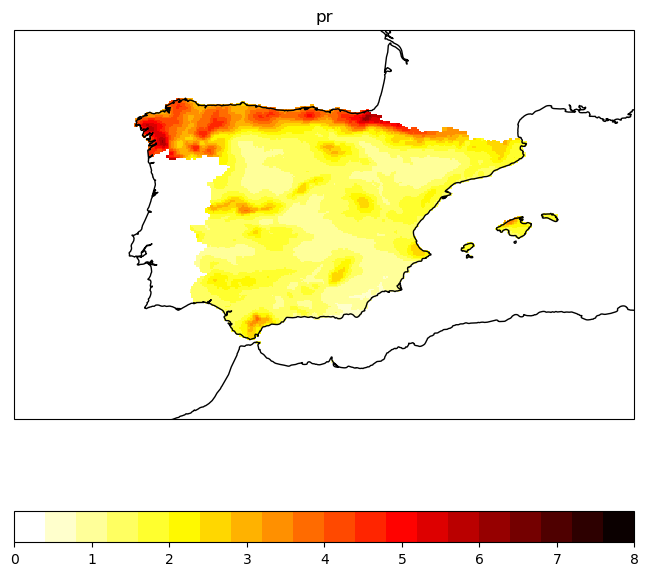

In [49]:
# Visualize the predictions
deep4downscaling.viz.simple_map_plot(data=pred_test.mean('time'),
                                     vlimits=(0, 8),
                                     colorbar='hot_r', var_to_plot='pr')

### References

[1] Baño-Medina, J., Manzanas, R., Cimadevilla, E., Fernández, J., González-Abad, J., Cofiño, A. S., & Gutiérrez, J. M. (2022). Downscaling multi-model climate projection ensembles with deep learning (DeepESD): Contribution to CORDEX EUR-44. Geoscientific Model Development Discussions, 2022, 1-14.

[2] Isola, P., Zhu, J. Y., Zhou, T., & Efros, A. A. (2017). Image-to-image translation with conditional adversarial networks. In Proceedings of the IEEE conference on computer vision and pattern recognition (pp. 1125-1134).